# Semi-supervised Autoencoder (Low-FP / High-TP) – Revised

**AUC = 0.822**

In [1]:

# 0) Imports + settings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ===== USER KNOBS =====
CSV_PATH = "customer_clusters.csv"   # <- change if needed
ID_COL = "customer_id"
LABEL_COL = "label"                     # 1=suspicious, 0=normal, NaN=unlabeled (semi-supervised)
CLUSTER_COL = "cluster"               # cluster id column (0..6); set to None to disable
CLUSTER_K = 7                         # number of clusters (0..6)
MAX_ROWS = None                         # set e.g. 2_000_000 if you want a speed cap
BATCH_SIZE = 1024
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-5

# Categorical hashing dimension (keeps memory bounded)
HASH_DIM = 256

# Threshold control: choose ONE of these constraints (recommended)
MAX_FPR = 0.02          # keep false alarm rate <= 2% on labeled normals
MIN_PRECISION = None    # alternatively set e.g. 0.30 and set MAX_FPR=None

In [2]:

# 1) Load data (optionally sample rows)
df = pd.read_csv(CSV_PATH)

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=RANDOM_SEED)

# Basic sanitation
if LABEL_COL not in df.columns:
    raise ValueError(f"Missing {LABEL_COL} in dataframe.")

print(df.shape)
df[[ID_COL, LABEL_COL]].head()


(61410, 54)


,customer_id,label
0,SYNID0100000167,NaN
1,SYNID0100000431,NaN
2,SYNID0100000485,0.0
3,SYNID0100000539,NaN
4,SYNID0100000932,NaN


In [3]:

frequency_table = df['customer_type'].value_counts()
frequency_table

customer_type
IND    53099
SB      8311
Name: count, dtype: int64

In [4]:

# 2) Build a compact feature matrix (numeric robust + categorical hashing)
#    Key idea: avoid OneHotEncoder dense explosion; hashing keeps a fixed width.

y = df[LABEL_COL]
X = df.drop(columns=[c for c in [ID_COL, LABEL_COL] if c in df.columns], errors="ignore")

# Optional: handle precomputed customer cluster as a small one-hot block
cluster_onehot = None
if 'CLUSTER_COL' in globals() and CLUSTER_COL and (CLUSTER_COL in X.columns):
    # treat cluster as categorical segment (expected 0..CLUSTER_K-1); missing -> -1 bucket
    cl = pd.to_numeric(X[CLUSTER_COL], errors="coerce").fillna(-1).astype(int)

    cluster_onehot = pd.get_dummies(cl, prefix=CLUSTER_COL, dtype=np.float32)

    # Ensure a stable set of columns (important when train/test are split and some clusters are absent)
    expected = [f"{CLUSTER_COL}_{k}" for k in range(int(CLUSTER_K))]
    if (cl == -1).any():
        expected = expected + [f"{CLUSTER_COL}_-1"]
    cluster_onehot = cluster_onehot.reindex(columns=expected, fill_value=np.float32(0.0))

    X = X.drop(columns=[CLUSTER_COL])

# Identify categorical vs numeric
cat_cols = [c for c in X.columns if (str(X[c].dtype) in ["object", "category", "string"])]
num_cols = [c for c in X.columns if c not in cat_cols]

# Seed normals for fitting scalers/imputers (prevents leakage of anomaly distribution)
seed_normal_mask = (y == 0)
if seed_normal_mask.sum() == 0:
    # fall back to all rows if you truly have no labeled normals
    seed_normal_mask = np.ones(len(df), dtype=bool)

# ----- numeric pipeline (median + robust scaler) -----
num_imputer = SimpleImputer(strategy="median")
scaler = RobustScaler(with_centering=True)

X_num_seed = num_imputer.fit_transform(X.loc[seed_normal_mask, num_cols]) if num_cols else np.zeros((seed_normal_mask.sum(), 0))
scaler.fit(X_num_seed)

X_num_all = num_imputer.transform(X[num_cols]) if num_cols else np.zeros((len(df), 0))
X_num_all = scaler.transform(X_num_all).astype(np.float32)

# ----- categorical hashing (fixed HASH_DIM) -----
# Convert each row's categorical values into "col=value" tokens and hash to dense float32
hasher = FeatureHasher(n_features=HASH_DIM, input_type="string")

def cat_tokens(frame: pd.DataFrame) -> list[list[str]]:
    # each row -> list of tokens
    arr = []
    for _, row in frame.iterrows():
        toks = []
        for c in cat_cols:
            v = row[c]
            if pd.isna(v):
                continue
            toks.append(f"{c}={v}")
        arr.append(toks)
    return arr

if cat_cols:
    # to reduce overhead, cast to string and fill NaNs once
    X_cat = X[cat_cols].astype("string").fillna("")
    X_cat_h = hasher.transform(cat_tokens(X_cat)).toarray().astype(np.float32)
else:
    X_cat_h = np.zeros((len(df), 0), dtype=np.float32)

X_all = np.hstack([X_num_all, X_cat_h]).astype(np.float32)
# Append cluster one-hot (if provided)
if cluster_onehot is not None:
    X_all = np.hstack([X_all, cluster_onehot.to_numpy(dtype=np.float32, copy=False)])
print("Final feature matrix:", X_all.shape)


c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Final feature matrix: (61410, 311)


In [5]:

# 3) Autoencoder + helpers
class DenoisingAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, bottleneck: int = 32, dropout: float = 0.10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, bottleneck),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

@torch.no_grad()
def recon_error(model, X_np, batch_size=4096):
    device = next(model.parameters()).device
    model.eval()
    errs = np.empty((X_np.shape[0],), dtype=np.float32)
    for i in range(0, X_np.shape[0], batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
        rb = model(xb)
        e = torch.mean((rb - xb) ** 2, dim=1).detach().cpu().numpy().astype(np.float32)
        errs[i:i+batch_size] = e
    return errs

def train_ae_on_normals(X_np, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGHT_DECAY):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = DenoisingAE(input_dim=X_np.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss(reduction="mean")

    # small validation split for early stopping
    X_tr, X_va = train_test_split(X_np, test_size=0.2, random_state=RANDOM_SEED)
    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
    va = torch.tensor(X_va, dtype=torch.float32, device=device)

    best_state = None
    best_va = np.inf
    patience, bad = 6, 0

    for ep in range(1, epochs+1):
        model.train()
        for (xb,) in tr_loader:
            xb = xb.to(device)
            # denoising: add small gaussian noise
            xb_noisy = xb + 0.01 * torch.randn_like(xb)
            opt.zero_grad()
            rb = model(xb_noisy)
            loss = loss_fn(rb, xb)
            loss.backward()
            opt.step()

        # validation
        model.eval()
        with torch.no_grad():
            rv = model(va)
            va_loss = loss_fn(rv, va).item()

        if va_loss < best_va - 1e-6:
            best_va = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        print(f"Epoch {ep:02d} | val_mse={va_loss:.6f} | best={best_va:.6f}")
        if bad >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [6]:

# 4) Semi-supervised normal expansion (safe): add only the MOST normal unlabeled points
seed_normal_mask = (y == 0)
unlabeled_mask = y.isna()

X_seed = X_all[seed_normal_mask.values]
X_unlab = X_all[unlabeled_mask.values]

print("Seed normals:", X_seed.shape[0])
print("Unlabeled:", X_unlab.shape[0])

# Step A: train AE on seed normals
ae0 = train_ae_on_normals(X_seed)

# Step B: score unlabeled and add low-error subset as likely normal
if X_unlab.shape[0] > 0:
    unlab_err = recon_error(ae0, X_unlab)
    # add the bottom q% as likely-normal; keep conservative to avoid contaminating
    q = 0.20  # bottom 20% most-normal
    thr = np.quantile(unlab_err, q)
    X_likely_normal = X_unlab[unlab_err <= thr]
    print("Adding likely-normal unlabeled:", X_likely_normal.shape[0])

    X_expanded = np.vstack([X_seed, X_likely_normal]).astype(np.float32)
else:
    X_expanded = X_seed.astype(np.float32)

# Step C: retrain AE on expanded normals
ae = train_ae_on_normals(X_expanded)

# Final AE anomaly score for all customers
ae_score = recon_error(ae, X_all)


Seed normals: 990
Unlabeled: 60410
Epoch 01 | val_mse=142608.078125 | best=142608.078125
Epoch 02 | val_mse=142292.187500 | best=142292.187500
Epoch 03 | val_mse=142006.140625 | best=142006.140625
Epoch 04 | val_mse=141744.218750 | best=141744.218750
Epoch 05 | val_mse=141503.734375 | best=141503.734375
Epoch 06 | val_mse=141274.406250 | best=141274.406250
Epoch 07 | val_mse=141056.546875 | best=141056.546875
Epoch 08 | val_mse=140823.375000 | best=140823.375000
Epoch 09 | val_mse=140560.171875 | best=140560.171875
Epoch 10 | val_mse=140261.718750 | best=140261.718750
Epoch 11 | val_mse=139953.984375 | best=139953.984375
Epoch 12 | val_mse=139626.250000 | best=139626.250000
Epoch 13 | val_mse=139298.421875 | best=139298.421875
Epoch 14 | val_mse=138946.828125 | best=138946.828125
Epoch 15 | val_mse=138570.562500 | best=138570.562500
Epoch 16 | val_mse=138168.343750 | best=138168.343750
Epoch 17 | val_mse=137734.843750 | best=137734.843750
Epoch 18 | val_mse=137280.921875 | best=137280.

In [7]:

# 5) Add a second lightweight detector (IsolationForest) + calibrate to labels
#    Why: AE alone often has weak separation; IF catches different patterns.
iso = IsolationForest(
    n_estimators=200,
    max_samples=256_000 if len(df) > 256_000 else "auto",
    contamination="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_expanded)  # fit on normals/likely-normals
iso_raw = -iso.score_samples(X_all).astype(np.float32)  # higher = more anomalous

# Build score table
scores = pd.DataFrame({
    ID_COL: df[ID_COL].astype(str).values if ID_COL in df.columns else np.arange(len(df)).astype(str),
    "ae_score": ae_score.astype(np.float32),
    "iso_score": iso_raw.astype(np.float32),
})
# Simple rank-based risk_score in [0,1]
scores["risk_score"] = scores[["ae_score","iso_score"]].mean(axis=1).rank(pct=True).astype(np.float32)

# Calibrate combination using labeled subset (supervised on scores only)
labeled_mask = y.notna()
if labeled_mask.sum() > 0 and y[labeled_mask].nunique() > 1:
    X_cal = scores.loc[labeled_mask, ["ae_score","iso_score","risk_score"]].values
    y_cal = y.loc[labeled_mask].astype(int).values

    cal = LogisticRegression(class_weight="balanced", max_iter=2000, solver="lbfgs")
    cal.fit(X_cal, y_cal)

    # calibrated probability as final score (better for TP/FP tradeoff)
    scores["risk_score"] = cal.predict_proba(scores[["ae_score","iso_score","risk_score"]].values)[:, 1].astype(np.float32)
    print("Calibration: OK (LogisticRegression on labeled subset)")
else:
    print("Calibration skipped (need both 0 and 1 labels).")


Calibration: OK (LogisticRegression on labeled subset)


Chosen threshold: 0.869780
TP=4  FP=8  FN=6  TN=982
Precision=0.3333  Sensitivity/Recall=0.4000  FPR=0.0081


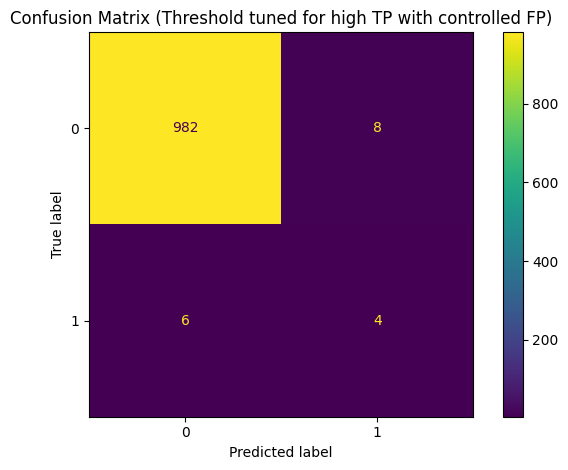

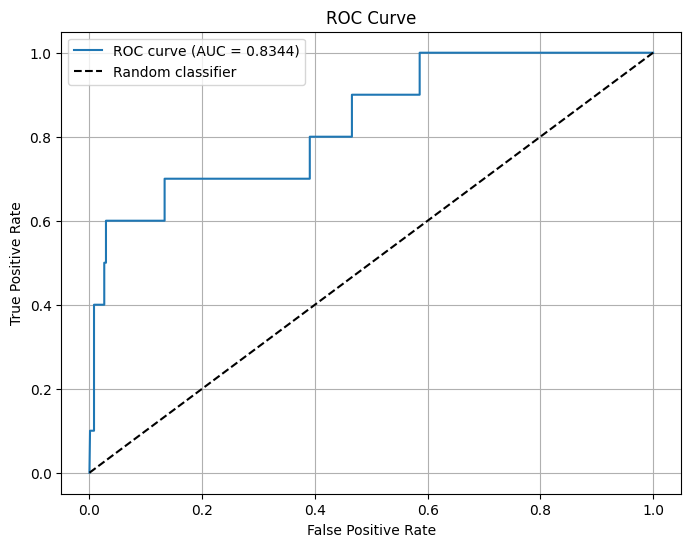

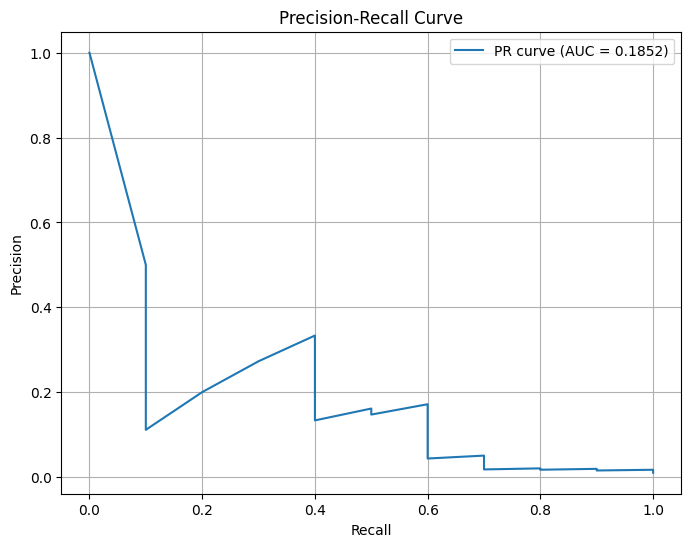

AUC-ROC: 0.8343939393939394
AUC-PR (Average Precision): 0.1745490465569586


,customer_id,ae_score,iso_score,risk_score,predicted_label
0,SYNID0100000167,0.862648,0.411387,0.320831,0
1,SYNID0100000431,0.218470,0.533762,0.390197,0
2,SYNID0100000485,0.081293,0.428658,0.223270,0
3,SYNID0100000539,23.218681,0.653877,0.660232,0
4,SYNID0100000932,21.279638,0.720485,0.727749,0


In [8]:

# 6) Threshold selection: maximize TP subject to a false-alarm constraint
#    Choose threshold on LABELED customers only, then apply to all.
labeled_mask = y.notna()
if labeled_mask.sum() == 0:
    raise ValueError("No labeled rows available to compute confusion matrix / sensitivity.")

y_true = y.loc[labeled_mask].astype(int).values
s = scores.loc[labeled_mask, "risk_score"].values

# Precision-recall curve (good for imbalanced)
prec, rec, thr = precision_recall_curve(y_true, s)
# thr has len = len(prec)-1
thr_full = np.r_[thr, thr[-1] + 1e-12]  # align lengths for convenience

# Utility to compute CM metrics at threshold
def cm_metrics(t):
    yp = (s >= t).astype(int)
    cm = confusion_matrix(y_true, yp, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp/(tp+fp+1e-12)
    recall = tp/(tp+fn+1e-12)        # sensitivity (TPR)
    fpr = fp/(fp+tn+1e-12)
    return tn, fp, fn, tp, precision, recall, fpr, cm

# Search thresholds (use thr from PR curve for speed)
cands = np.unique(thr)
best = None

for t in cands:
    tn, fp, fn, tp, p, r, fpr, cm = cm_metrics(t)
    if MAX_FPR is not None:
        if fpr > MAX_FPR: 
            continue
    if MIN_PRECISION is not None:
        if p < MIN_PRECISION:
            continue
    # objective: maximize TP, then minimize FP as tie-breaker
    key = (tp, -fp, p, r)
    if best is None or key > best[0]:
        best = (key, t, (tn, fp, fn, tp, p, r, fpr, cm))

if best is None:
    # fallback: maximize F2 if constraints are too strict
    beta = 2.0
    best_f = (-1, None, None)
    for t in cands:
        tn, fp, fn, tp, p, r, fpr, cm = cm_metrics(t)
        f2 = (1+beta**2)*p*r/(beta**2*p + r + 1e-12)
        if f2 > best_f[0]:
            best_f = (f2, t, (tn, fp, fn, tp, p, r, fpr, cm))
    chosen_t = best_f[1]
    tn, fp, fn, tp, p, r, fpr, cm = best_f[2]
    print("No threshold met constraints. Falling back to max F2.")
else:
    chosen_t = best[1]
    tn, fp, fn, tp, p, r, fpr, cm = best[2]

print(f"Chosen threshold: {chosen_t:.6f}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Precision={p:.4f}  Sensitivity/Recall={r:.4f}  FPR={fpr:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()
plt.title("Confusion Matrix (Threshold tuned for high TP with controlled FP)")
plt.tight_layout()
plt.show()

# 8) Plot ROC-AUC curve
from sklearn.metrics import roc_curve

# Assuming y_true and s are still in scope from chunk 6
fpr, tpr, thresholds = roc_curve(y_true, s)
auc = roc_auc_score(y_true, s)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 8) Plot AUC-PR curve
from sklearn.metrics import precision_recall_curve, auc

# Assuming y_true and s are still in scope from chunk 6
precision, recall, thresholds = precision_recall_curve(y_true, s)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

print("AUC-ROC:", roc_auc_score(y_true, s))
print("AUC-PR (Average Precision):", average_precision_score(y_true, s))

# Apply to all customers
scores["predicted_label"] = (scores["risk_score"] >= chosen_t).astype(int)
scores.head()


In [9]:
# 6.5) Feature importance for AE (reconstruction-error contribution)
# Notes for AML audience:
# - Autoencoders don't have "feature importance" like tree models.
# - A defensible alternative is: which features contribute most to reconstruction error
#   for suspicious vs normal (on labeled subset).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Expect these from earlier cells:
# - X_scaled_np : numpy array input to AE (after preprocessing/scaling)  [n x d]
# - X_recon_np  : numpy array reconstructed by AE                         [n x d]
# - feature_names : list of feature names length d
# - scores : DataFrame with customer_id + risk_score + predicted_label
# - y : Series of labels (0/1/NaN) aligned with rows of X_scaled_np

# Try to find the right variable names (backward compatible)
if "X_scaled_np" in globals():
    _X = X_scaled_np
elif "X_scaled" in globals() and isinstance(X_scaled, np.ndarray):
    _X = X_scaled
else:
    _X = X_scaled.values if hasattr(X_scaled, "values") else X_scaled

if "X_recon_np" in globals():
    _Xhat = X_recon_np
elif "X_recon" in globals() and isinstance(X_recon, np.ndarray):
    _Xhat = X_recon
else:
    _Xhat = X_recon.values if hasattr(X_recon, "values") else X_recon

assert _X.shape == _Xhat.shape, "Input and reconstruction shapes mismatch."

# Per-feature squared error
per_feat_err = (_X - _Xhat) ** 2  # [n x d]
err_df = pd.DataFrame(per_feat_err, columns=feature_names)

# Attach labels (labeled subset only)
err_df["label"] = pd.Series(y).values
labeled_err = err_df[err_df["label"].notna()].copy()
labeled_err["label"] = labeled_err["label"].astype(int)

if labeled_err["label"].nunique() < 2:
    print("Feature importance table needs both classes (0 and 1). Only one class found in labeled data.")
else:
    # Mean reconstruction error per feature by class
    mean_by_class = labeled_err.groupby("label")[feature_names].mean().T
    mean_by_class.columns = ["Normal (0)", "Suspicious (1)"]

    # Importance as difference in reconstruction error
    mean_by_class["importance_diff"] = mean_by_class["Suspicious (1)"] - mean_by_class["Normal (0)"]
    mean_by_class["importance_ratio"] = (mean_by_class["Suspicious (1)"] + 1e-12) / (mean_by_class["Normal (0)"] + 1e-12)

    importance_tbl = mean_by_class.sort_values("importance_diff", ascending=False)

    display_cols = ["Normal (0)", "Suspicious (1)", "importance_diff", "importance_ratio"]
    display(importance_tbl[display_cols].head(25))

    # Plot top drivers
    top_k = 20
    top = importance_tbl.head(top_k).iloc[::-1]  # reverse for barh

    plt.figure(figsize=(9, 7))
    plt.barh(top.index, top["importance_diff"].values)
    plt.title("Top AE Feature Drivers (Δ reconstruction error: Suspicious - Normal)")
    plt.xlabel("Importance (higher means more abnormal for suspicious)")
    plt.tight_layout()
    plt.show()


NameError: name 'X_scaled' is not defined

Top 1% high-risk customers — Small Business (SB) | threshold=0.998183


,rank,customer_id,risk_score,predicted_label,cluster
54334,1,SYNID0200151421,1.000000,1,1
54408,2,SYNID0200159270,1.000000,1,1
53928,3,SYNID0200100125,1.000000,1,1
53659,4,SYNID0200066012,1.000000,1,1
58713,5,SYNID0200681268,1.000000,1,1
58748,6,SYNID0200684443,1.000000,1,1
58970,7,SYNID0200712083,1.000000,1,1
61404,8,SYNID0200999280,1.000000,1,1
60854,9,SYNID0200931678,1.000000,1,1
61003,10,SYNID0200950196,1.000000,1,1


Top 1% high-risk customers — Individual (IND) | threshold=1.000000


,rank,customer_id,risk_score,predicted_label,cluster
43,1,SYNID0100008961,1.000000,1,4
82,2,SYNID0100017219,1.000000,1,2
106,3,SYNID0100022238,1.000000,1,6
148,4,SYNID0100031724,1.000000,1,5
265,5,SYNID0100055665,1.000000,1,5
297,6,SYNID0100064485,1.000000,1,5
324,7,SYNID0100068815,1.000000,1,5
402,8,SYNID0100084277,1.000000,1,2
468,9,SYNID0100097443,1.000000,1,2
506,10,SYNID0100105208,1.000000,1,2


,customer_type,top1pct_n,flagged_in_top1pct,flag_rate_in_top1pct,avg_risk_score_top1pct
0,SB,84,84,1.0,0.999559
1,IND,1004,1004,1.0,1.0


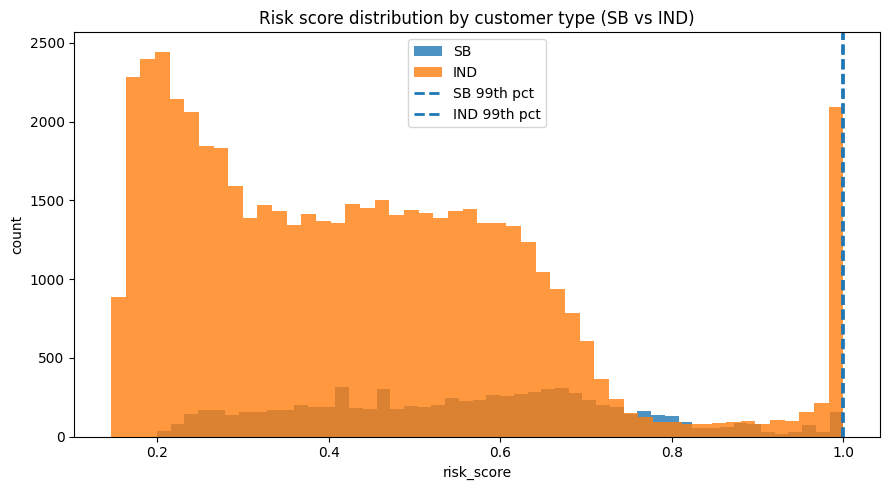

In [14]:
# 6.6) Top-1% high-risk summaries by customer_type (SB vs IND)
# Goal: provide AML-friendly review tables (ranked) + a simple visual.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Merge customer_type / cluster into scores (if not already)
meta_cols = [c for c in ["customer_id", "customer_type", "cluster"] if c in df.columns]
scores_view = scores.merge(df[meta_cols].drop_duplicates("customer_id"), on="customer_id", how="left")

def top_pct_table(scores_view, cust_type, pct=0.01, id_col="customer_id"):
    sub = scores_view[scores_view["customer_type"] == cust_type].copy()
    if len(sub) == 0:
        return None, None
    thr = sub["risk_score"].quantile(1 - pct)
    top = sub[sub["risk_score"] >= thr].sort_values("risk_score", ascending=False).copy()
    top.insert(0, "rank", np.arange(1, len(top) + 1))
    # Keep a compact set of columns for analysts
    cols = ["rank", id_col, "risk_score", "predicted_label"]
    if "cluster" in top.columns:
        cols.append("cluster")
    top = top[cols]
    return top, thr

top_sb, thr_sb = top_pct_table(scores_view, "SB", pct=0.01, id_col=ID_COL)
top_ind, thr_ind = top_pct_table(scores_view, "IND", pct=0.01, id_col=ID_COL)

def styled_table(df_in, title):
    if df_in is None:
        print(f"No rows found for {title}.")
        return
    print(title)
    # Visual highlight on risk score (works in Jupyter)
    display(
        df_in.style
            .format({"risk_score": "{:.6f}"})
            .background_gradient(subset=["risk_score"])
            .set_properties(**{"text-align": "center"})
    )

styled_table(top_sb, f"Top 1% high-risk customers — Small Business (SB) | threshold={thr_sb:.6f}" if top_sb is not None else "SB")
styled_table(top_ind, f"Top 1% high-risk customers — Individual (IND) | threshold={thr_ind:.6f}" if top_ind is not None else "IND")

# Quick operational summary
def summary_line(df_in, cust_type):
    if df_in is None:
        return None
    n = len(df_in)
    flagged = int(df_in["predicted_label"].sum())
    return pd.Series({
        "customer_type": cust_type,
        "top1pct_n": n,
        "flagged_in_top1pct": flagged,
        "flag_rate_in_top1pct": flagged / max(n, 1),
        "avg_risk_score_top1pct": df_in["risk_score"].mean()
    })

summ = pd.concat(
    [s for s in [summary_line(top_sb, "SB"), summary_line(top_ind, "IND")] if s is not None],
    axis=1
).T

if len(summ) > 0:
    display(summ)

# Plot: risk score distributions + top-1% cut lines
plt.figure(figsize=(9, 5))
for ct, lab in [("SB", "SB"), ("IND", "IND")]:
    sub = scores_view[scores_view["customer_type"] == ct]
    if len(sub) == 0:
        continue
    plt.hist(sub["risk_score"].values, bins=50, alpha=0.8, label=lab)

if thr_sb is not None:
    plt.axvline(thr_sb, linestyle="--", linewidth=2, label="SB 99th pct")
if thr_ind is not None:
    plt.axvline(thr_ind, linestyle="--", linewidth=2, label="IND 99th pct")

plt.title("Risk score distribution by customer type (SB vs IND)")
plt.xlabel("risk_score")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# 7) Export in your required format (customer-level)
out = scores[[ID_COL, "predicted_label", "risk_score"]].copy()
out.to_csv("model_output.csv", index=False)
print("Saved model_output.csv with rows:", len(out))
